In [10]:
import os
import numpy as np
import pandas as pd
from dotenv import load_dotenv
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

load_dotenv()

DAILY_FILE_ID = os.getenv("PJME_DAILY_FILE_ID")
HOURLY_FILE_ID = os.getenv("PJME_HOURLY_FILE_ID")

def load_from_gdrive(file_id):
    url = f"https://drive.google.com/uc?id={file_id}"
    return pd.read_csv(url, index_col= 0, parse_dates= True)

pjme_daily = load_from_gdrive(DAILY_FILE_ID)
pjme_hourly = load_from_gdrive(HOURLY_FILE_ID)


sns.set(style = "whitegrid")
plt.rcParams["figure.figsize"] = (15,6)

In [11]:
pjme_daily

,PJME
2002-01-01,31080.739130
2002-01-02,34261.541667
2002-01-03,34511.875000
2002-01-04,33715.458333
2002-01-05,30405.125000
...,...
2018-07-30,32957.416667
2018-07-31,34539.083333
2018-08-01,39230.791667
2018-08-02,39593.041667


In [12]:
def run_stationarity_tests(series, title):

    adf_result = adfuller(series.dropna())
    print(f"ADF p-value: {adf_result[1]:.6f}")

    kpss_result = kpss(series.dropna(), regression='c', nlags="auto")
    print(f"KPSS p-value: {kpss_result[1]:.6f}")

    if adf_result[1] < 0.05:
        print("Series is stationary")

    else:
        print("Series is NOT stationary")

run_stationarity_tests(pjme_daily['PJME'], 'Daily Data')

ADF p-value: 0.000000
KPSS p-value: 0.100000
Series is stationary


/var/folders/8p/ym97qvfj5p3cqhq47g7vmvgm0000gn/T/ipykernel_32195/2017564875.py:6: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_result = kpss(series.dropna(), regression='c', nlags="auto")


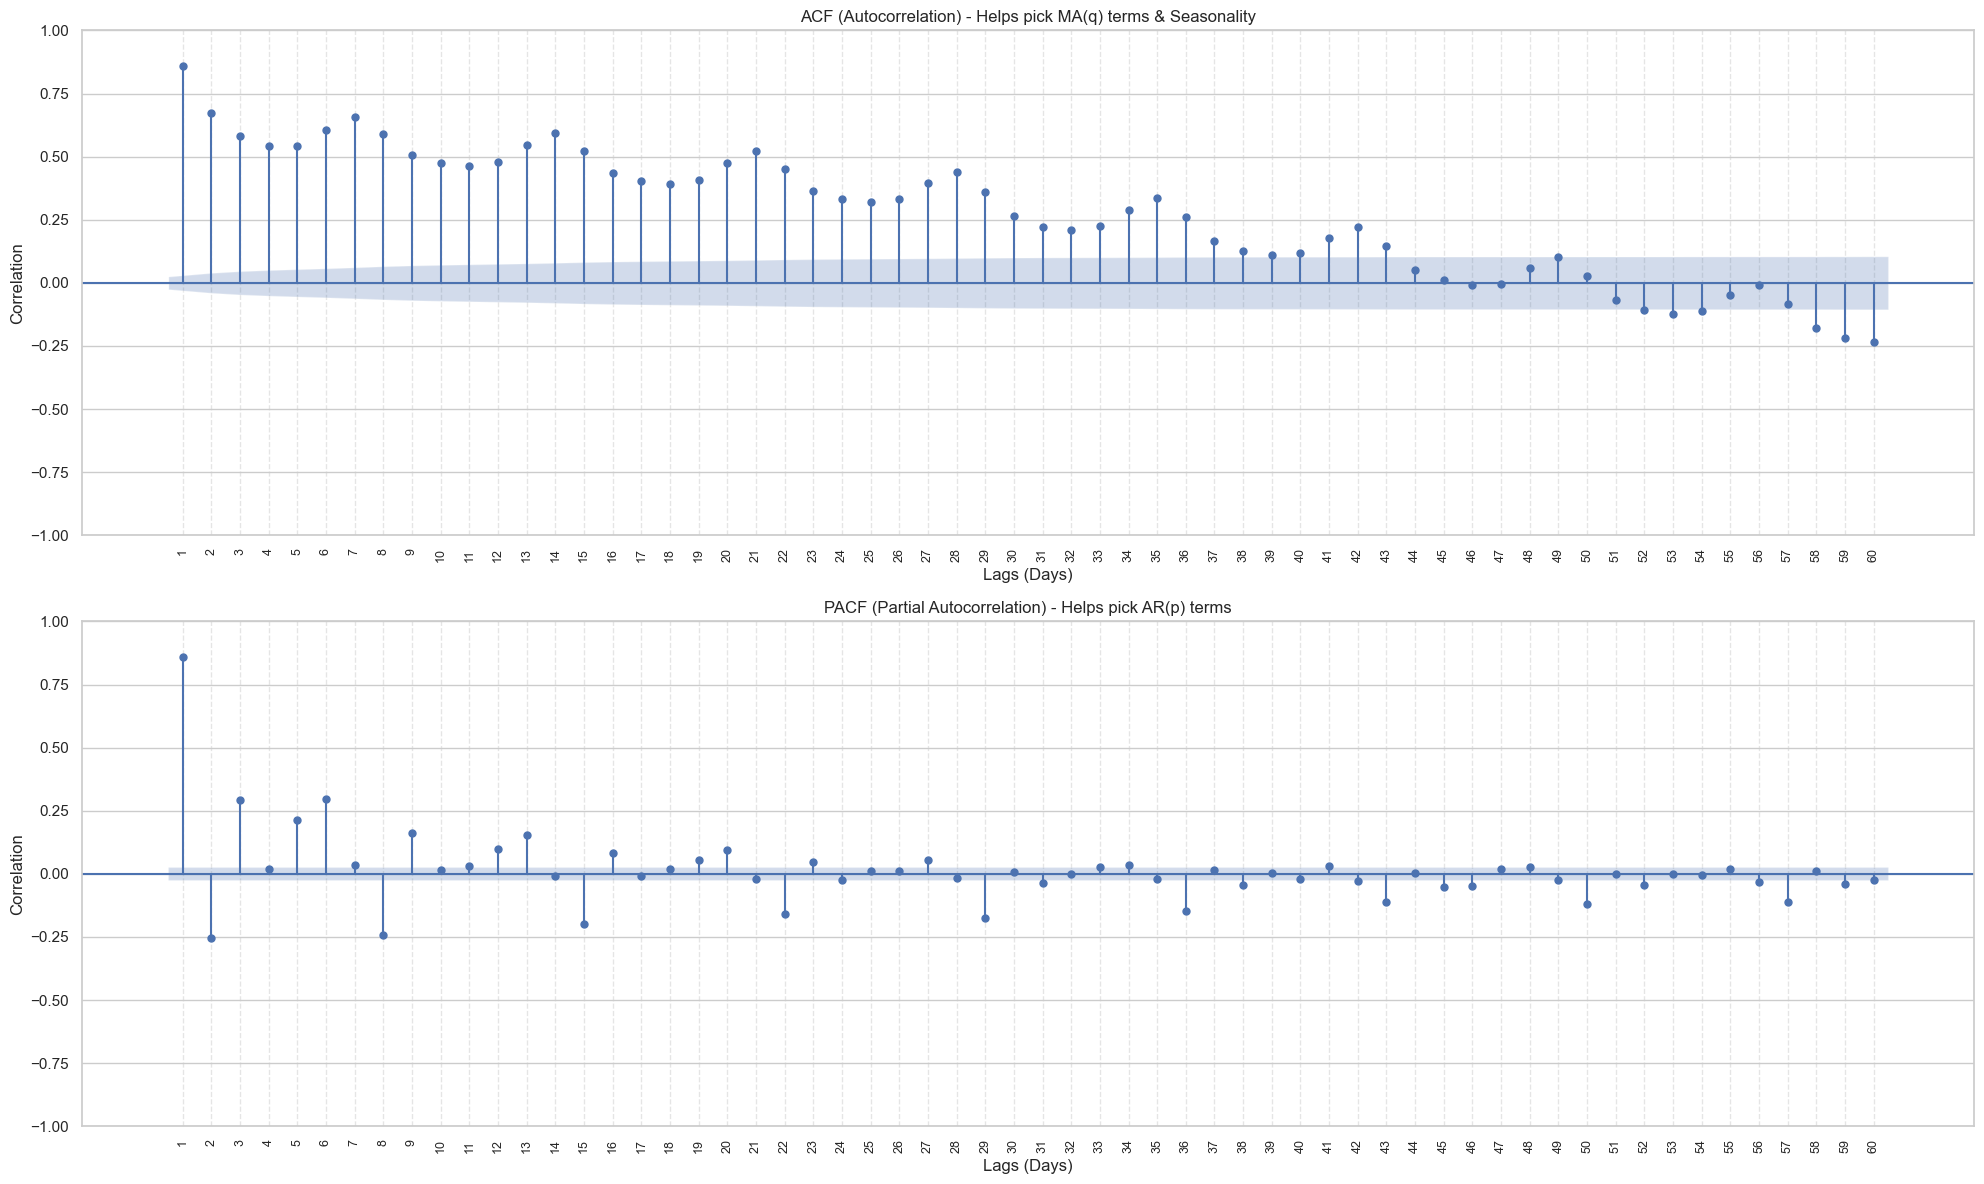

In [13]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(20, 12))

#ACF
plot_acf(pjme_daily['PJME'], lags=60, ax=ax1, zero=False)
ax1.set_title("ACF (Autocorrelation) - Helps pick MA(q) terms & Seasonality")
ax1.set_xticks(np.arange(1, 61))
ax1.set_xticklabels(np.arange(1, 61), rotation=90, fontsize=9)
ax1.grid(True, which='both', axis='x', linestyle='--', alpha=0.5)
ax1.set_xlabel("Lags (Days)")
ax1.set_ylabel("Correlation")

#PACF
plot_pacf(pjme_daily['PJME'], lags=60, ax=ax2, zero=False)
ax2.set_title("PACF (Partial Autocorrelation) - Helps pick AR(p) terms")
ax2.set_xticks(np.arange(1, 61))
ax2.set_xticklabels(np.arange(1, 61), rotation=90, fontsize=9)
ax2.grid(True, which='both', axis='x', linestyle='--', alpha=0.5)
ax2.set_xlabel("Lags (Days)")
ax2.set_ylabel("Correlation")

plt.tight_layout()
plt.show()

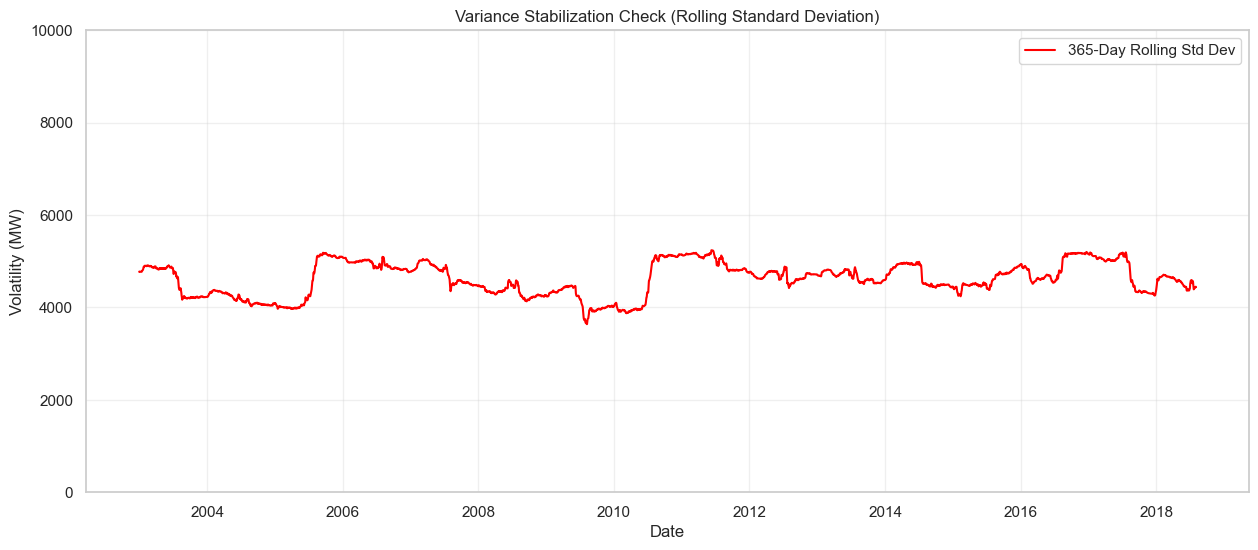

In [16]:
rolling_std = pjme_daily['PJME'].rolling(window=365).std()

plt.figure(figsize=(15, 6))
plt.plot(rolling_std, color='red', label='365-Day Rolling Std Dev')

plt.ylim(0, 10000)
plt.title('Variance Stabilization Check (Rolling Standard Deviation)')
plt.ylabel('Volatility (MW)')
plt.xlabel('Date')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Variance Analysis Conclusion
The plot above displays the rolling standard deviation of daily energy consumption over a 365-day window.

* **Observation:** The standard deviation fluctuates (between ~4,000 and 6,000 MW) but does not show a consistent long-term upward trend. The volatility is relatively stable over the 16-year period.
* **Decision:** The variance is sufficiently stable (homoscedastic). **Logarithmic transformation is not required.** We will proceed with the raw data.

# Phase 2: Examining Time Series Properties

In this phase, we performed a statistical analysis of the daily energy consumption data to determine its properties and identify the appropriate parameters for modeling.

### 1. Stationarity Analysis
We applied two complementary statistical tests to verify if the time series is stationary (i.e., has a stable mean and variance over time).

* **Augmented Dickey-Fuller (ADF) Test**
    * **Null Hypothesis ($H_0$):** The series is non-stationary (contains a unit root).
    * **Result:** The p-value was **0.0000** ($< 0.05$).
    * **Conclusion:** We **reject** the null hypothesis. The data is stationary.

* **KPSS Test**
    * **Null Hypothesis ($H_0$):** The series is stationary around a deterministic trend.
    * **Result:** The p-value was **0.1000** ($> 0.05$).
    * **Conclusion:** We **fail to reject** the null hypothesis. The data is stationary.

> **Verdict: Both the ADF and KPSS tests confirm that the daily energy consumption series is stationary.**
>
> * **Statistical Confirmation:** The rejection of the ADF null hypothesis ($p < 0.05$) proves the data does not wander randomly (no unit root).
> * **Visual Confirmation:** The series fluctuates around a constant long-term mean (roughly 35,000 MW) without exhibiting a significant upward or downward slope over the 16-year period.
> * **Modeling Implication:** Since the data is effectively *"stationary around a flat trend,"* **no non-seasonal differencing is required ($d=0$)**. We can model the raw values directly, as the "mean" of the series remains stable over time.

---

### 2. Autocorrelation Analysis (ACF & PACF)
We generated Autocorrelation (ACF) and Partial Autocorrelation (PACF) plots to diagnose seasonality and lag dependencies.

* **ACF (AutoCorrelation Function):** The plot reveals clear, repeating spikes at **Lags 7, 14, 21, and 28**. This confirms strong **weekly seasonality** (7-day cycle).
* **PACF (Partial AutoCorrelation Function):** The plot shows a dominant sharp cut-off at **Lag 1**, indicating that the previous day's value is the strongest direct predictor of the current day.

---

### 3. Recommendations for Modeling (Phase 3)
Based on these statistical properties, we will be implementing this model: 

* **Model Type:** **SARIMA** (Seasonal ARIMA) is necessary to capture the weekly cycle, as a standard ARIMA model would miss the seasonal signal.
* **Parameter Selection:**
    * **Trend Component:** $d=0$ (Stationary).
    * **AutoRegressive Component:** Start with $p=1$ or $p=2$ (based on PACF Lag 1).
    * **Seasonality:** The seasonal period must be set to **$m=7$**.